In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [11]:
results_path = "results/experiment1/experiment1_results.pkl"

with open(results_path, 'rb') as f:
    results = pickle.load(f)

# Extract data
vae_elbo = results['vae_elbo']          # [num_datapoints, k_reruns]
iwae_elbo = results['iwae_elbo']        # [num_datapoints, k_reruns]
conv_steps = results['convergence_steps']  # [num_datapoints, k_reruns]
metadata = results['metadata']

print("=" * 80)
print("EXPERIMENT 1: CONVERGENCE VALIDATION ANALYSIS")
print("=" * 80)
print(f"Dataset: {metadata['dataset']}")
print(f"Number of datapoints: {metadata['num_datapoints']}")
print(f"Number of reruns per datapoint: {metadata['k_reruns']}")
print(f"IWAE samples: {metadata['k_iwae']}")
print("=" * 80 + "\n")

EXPERIMENT 1: CONVERGENCE VALIDATION ANALYSIS
Dataset: mnist
Number of datapoints: 100
Number of reruns per datapoint: 10
IWAE samples: 100



In [12]:
per_dp_stats = {
    'mean_vae': np.mean(vae_elbo, axis=1),
    'std_vae': np.std(vae_elbo, axis=1),
    'min_vae': np.min(vae_elbo, axis=1),
    'max_vae': np.max(vae_elbo, axis=1),
    'range_vae': np.max(vae_elbo, axis=1) - np.min(vae_elbo, axis=1),
    
    'mean_iwae': np.mean(iwae_elbo, axis=1),
    'std_iwae': np.std(iwae_elbo, axis=1),
    'min_iwae': np.min(iwae_elbo, axis=1),
    'max_iwae': np.max(iwae_elbo, axis=1),
    'range_iwae': np.max(iwae_elbo, axis=1) - np.min(iwae_elbo, axis=1),
    
    'mean_steps': np.mean(conv_steps, axis=1),
    'std_steps': np.std(conv_steps, axis=1),
}

print("\n" + "=" * 80)
print("PER-DATAPOINT STATISTICS SUMMARY")
print("=" * 80)
print("\nVAE ELBO:")
print(f"  Mean std across datapoints: {np.mean(per_dp_stats['std_vae']):.6f}")
print(f"  Max std: {np.max(per_dp_stats['std_vae']):.6f}")
print(f"  Mean range: {np.mean(per_dp_stats['range_vae']):.6f}")
print(f"  Max range: {np.max(per_dp_stats['range_vae']):.6f}")

print("\nIWAE ELBO:")
print(f"  Mean std across datapoints: {np.mean(per_dp_stats['std_iwae']):.6f}")
print(f"  Max std: {np.max(per_dp_stats['std_iwae']):.6f}")
print(f"  Mean range: {np.mean(per_dp_stats['range_iwae']):.6f}")
print(f"  Max range: {np.max(per_dp_stats['range_iwae']):.6f}")

print("\nConvergence Steps:")
print(f"  Mean: {np.mean(per_dp_stats['mean_steps']):.1f}")
print(f"  Std: {np.std(per_dp_stats['mean_steps']):.1f}")


PER-DATAPOINT STATISTICS SUMMARY

VAE ELBO:
  Mean std across datapoints: 0.161811
  Max std: 0.285983
  Mean range: 0.539168
  Max range: 0.989090

IWAE ELBO:
  Mean std across datapoints: 0.382732
  Max std: 1.557191
  Mean range: 1.300571
  Max range: 4.751541

Convergence Steps:
  Mean: 19278.7
  Std: 1084.8


In [13]:
# Define thresholds for "unreliable" datapoints
STD_THRESHOLD = 0.5  # nats
RANGE_THRESHOLD = 1.0  # nats

# Flag unreliable datapoints
unreliable_std_vae = per_dp_stats['std_vae'] > STD_THRESHOLD
unreliable_range_vae = per_dp_stats['range_vae'] > RANGE_THRESHOLD
unreliable_std_iwae = per_dp_stats['std_iwae'] > STD_THRESHOLD
unreliable_range_iwae = per_dp_stats['range_iwae'] > RANGE_THRESHOLD

# Combined flag: unreliable if EITHER std OR range exceeds threshold
unreliable_vae = unreliable_std_vae | unreliable_range_vae
unreliable_iwae = unreliable_std_iwae | unreliable_range_iwae

print("\n" + "=" * 80)
print("RELIABILITY ANALYSIS")
print("=" * 80)
print(f"Thresholds: std > {STD_THRESHOLD} nats OR range > {RANGE_THRESHOLD} nats")
print(f"\nVAE ELBO:")
print(f"  Unreliable by std: {np.sum(unreliable_std_vae)} / {len(unreliable_std_vae)} ({100*np.mean(unreliable_std_vae):.1f}%)")
print(f"  Unreliable by range: {np.sum(unreliable_range_vae)} / {len(unreliable_range_vae)} ({100*np.mean(unreliable_range_vae):.1f}%)")
print(f"  Total unreliable: {np.sum(unreliable_vae)} / {len(unreliable_vae)} ({100*np.mean(unreliable_vae):.1f}%)")

print(f"\nIWAE ELBO:")
print(f"  Unreliable by std: {np.sum(unreliable_std_iwae)} / {len(unreliable_std_iwae)} ({100*np.mean(unreliable_std_iwae):.1f}%)")
print(f"  Unreliable by range: {np.sum(unreliable_range_iwae)} / {len(unreliable_range_iwae)} ({100*np.mean(unreliable_range_iwae):.1f}%)")
print(f"  Total unreliable: {np.sum(unreliable_iwae)} / {len(unreliable_iwae)} ({100*np.mean(unreliable_iwae):.1f}%)")

# Show worst cases
print("\nWorst 5 datapoints by variance (VAE ELBO):")
worst_idx = np.argsort(per_dp_stats['std_vae'])[-5:][::-1]
for rank, idx in enumerate(worst_idx, 1):
    print(f"  {rank}. Datapoint {idx}: std={per_dp_stats['std_vae'][idx]:.6f}, range={per_dp_stats['range_vae'][idx]:.6f}")


RELIABILITY ANALYSIS
Thresholds: std > 0.5 nats OR range > 1.0 nats

VAE ELBO:
  Unreliable by std: 0 / 100 (0.0%)
  Unreliable by range: 0 / 100 (0.0%)
  Total unreliable: 0 / 100 (0.0%)

IWAE ELBO:
  Unreliable by std: 18 / 100 (18.0%)
  Unreliable by range: 58 / 100 (58.0%)
  Total unreliable: 58 / 100 (58.0%)

Worst 5 datapoints by variance (VAE ELBO):
  1. Datapoint 33: std=0.285983, range=0.989090
  2. Datapoint 66: std=0.264247, range=0.976143
  3. Datapoint 65: std=0.259183, range=0.798019
  4. Datapoint 87: std=0.255721, range=0.714020
  5. Datapoint 13: std=0.242543, range=0.749153


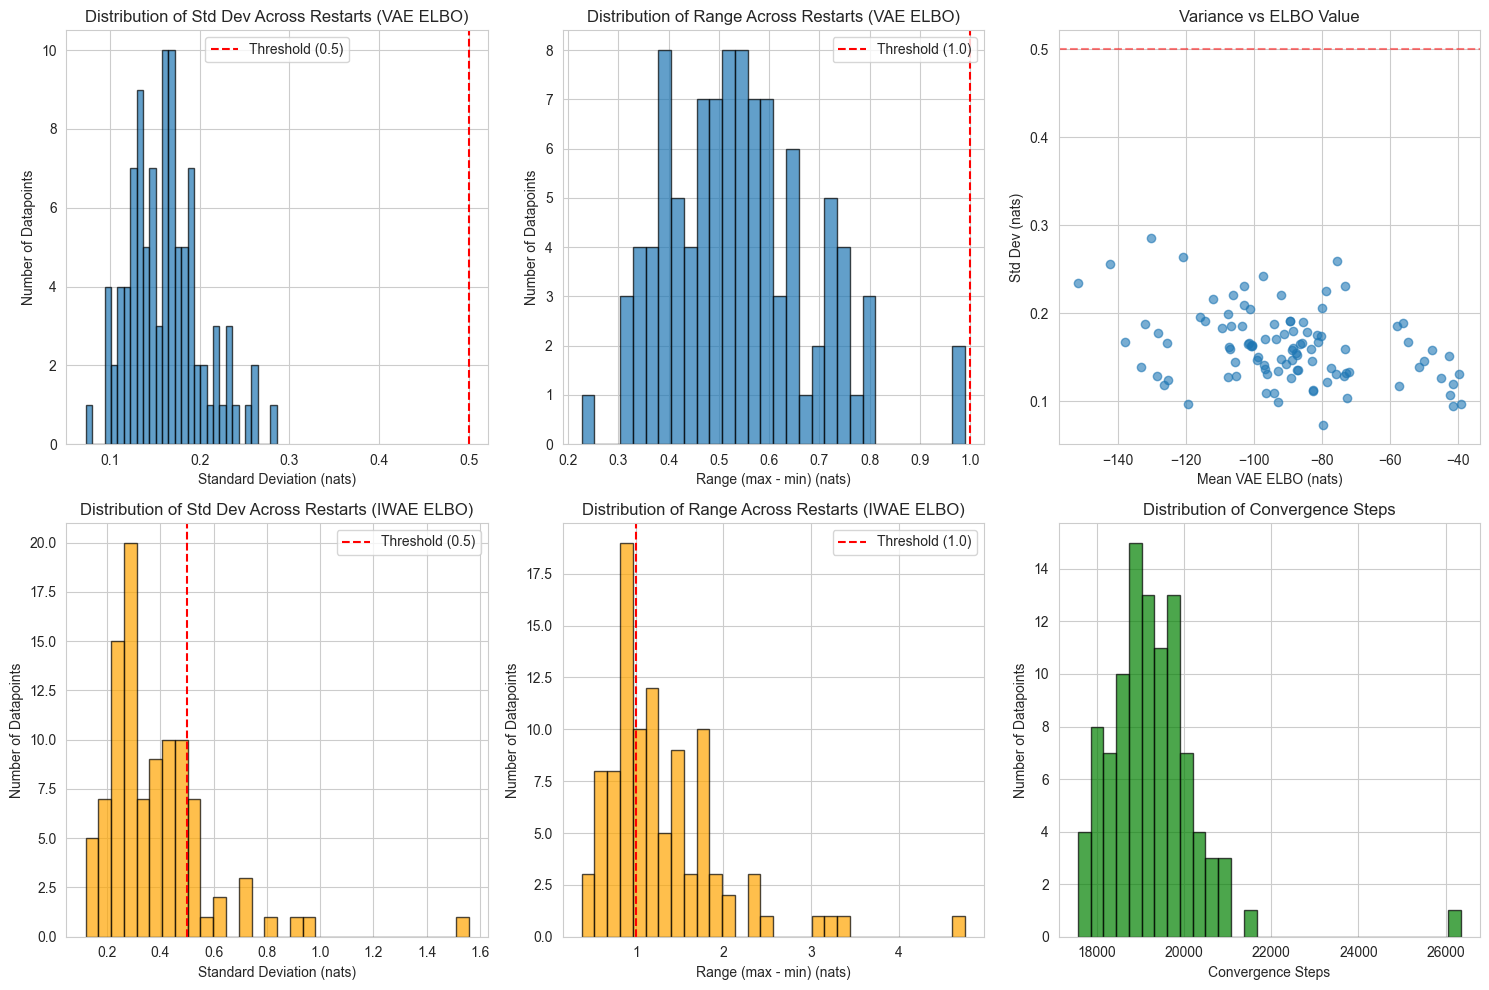

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 4.1 Distribution of standard deviations
axes[0, 0].hist(per_dp_stats['std_vae'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(STD_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({STD_THRESHOLD})')
axes[0, 0].set_xlabel('Standard Deviation (nats)')
axes[0, 0].set_ylabel('Number of Datapoints')
axes[0, 0].set_title('Distribution of Std Dev Across Restarts (VAE ELBO)')
axes[0, 0].legend()

# 4.2 Distribution of ranges
axes[0, 1].hist(per_dp_stats['range_vae'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(RANGE_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({RANGE_THRESHOLD})')
axes[0, 1].set_xlabel('Range (max - min) (nats)')
axes[0, 1].set_ylabel('Number of Datapoints')
axes[0, 1].set_title('Distribution of Range Across Restarts (VAE ELBO)')
axes[0, 1].legend()

# 4.3 Scatter: std vs mean ELBO
axes[0, 2].scatter(per_dp_stats['mean_vae'], per_dp_stats['std_vae'], alpha=0.6)
axes[0, 2].axhline(STD_THRESHOLD, color='red', linestyle='--', alpha=0.5)
axes[0, 2].set_xlabel('Mean VAE ELBO (nats)')
axes[0, 2].set_ylabel('Std Dev (nats)')
axes[0, 2].set_title('Variance vs ELBO Value')

# 4.4 Same for IWAE
axes[1, 0].hist(per_dp_stats['std_iwae'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].axvline(STD_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({STD_THRESHOLD})')
axes[1, 0].set_xlabel('Standard Deviation (nats)')
axes[1, 0].set_ylabel('Number of Datapoints')
axes[1, 0].set_title('Distribution of Std Dev Across Restarts (IWAE ELBO)')
axes[1, 0].legend()

# 4.5 Range for IWAE
axes[1, 1].hist(per_dp_stats['range_iwae'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(RANGE_THRESHOLD, color='red', linestyle='--', label=f'Threshold ({RANGE_THRESHOLD})')
axes[1, 1].set_xlabel('Range (max - min) (nats)')
axes[1, 1].set_ylabel('Number of Datapoints')
axes[1, 1].set_title('Distribution of Range Across Restarts (IWAE ELBO)')
axes[1, 1].legend()

# 4.6 Convergence steps distribution
axes[1, 2].hist(per_dp_stats['mean_steps'].flatten(), bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1, 2].set_xlabel('Convergence Steps')
axes[1, 2].set_ylabel('Number of Datapoints')
axes[1, 2].set_title('Distribution of Convergence Steps')

plt.tight_layout()
plt.savefig('results/experiment1/reliability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

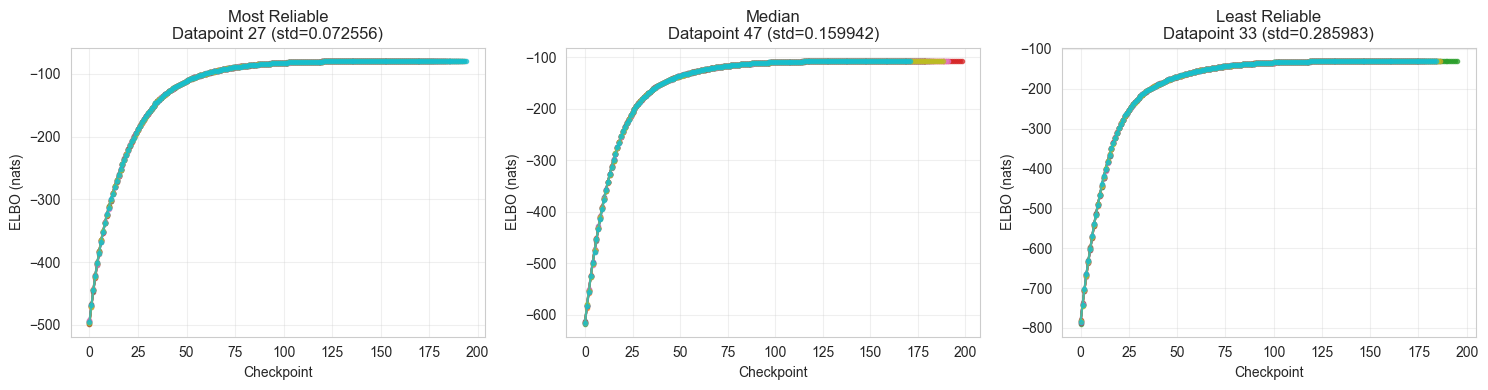

In [15]:
trajectories = results['trajectories']

# Pick 3 examples: best, median, worst variance
best_idx = np.argmin(per_dp_stats['std_vae'])
median_idx = np.argsort(per_dp_stats['std_vae'])[len(per_dp_stats['std_vae'])//2]
worst_idx = np.argmax(per_dp_stats['std_vae'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, idx, title in zip(axes, 
                          [best_idx, median_idx, worst_idx],
                          ['Most Reliable', 'Median', 'Least Reliable']):
    for k in range(metadata['k_reruns']):
        traj = trajectories[idx][k]
        ax.plot(range(len(traj)), traj, alpha=0.7, marker='o', markersize=3)
    
    ax.set_xlabel('Checkpoint')
    ax.set_ylabel('ELBO (nats)')
    ax.set_title(f'{title}\nDatapoint {idx} (std={per_dp_stats["std_vae"][idx]:.6f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/experiment1/convergence_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("\n" + "=" * 80)
print("SUMMARY TABLE FOR PRESENTATION")
print("=" * 80)

summary_data = {
    'Metric': ['Mean std', 'Max std', 'Mean range', 'Max range', 
               '% unreliable (std)', '% unreliable (range)', '% unreliable (total)'],
    'VAE ELBO': [
        f"{np.mean(per_dp_stats['std_vae']):.6f}",
        f"{np.max(per_dp_stats['std_vae']):.6f}",
        f"{np.mean(per_dp_stats['range_vae']):.6f}",
        f"{np.max(per_dp_stats['range_vae']):.6f}",
        f"{100*np.mean(unreliable_std_vae):.1f}%",
        f"{100*np.mean(unreliable_range_vae):.1f}%",
        f"{100*np.mean(unreliable_vae):.1f}%",
    ],
    'IWAE ELBO': [
        f"{np.mean(per_dp_stats['std_iwae']):.6f}",
        f"{np.max(per_dp_stats['std_iwae']):.6f}",
        f"{np.mean(per_dp_stats['range_iwae']):.6f}",
        f"{np.max(per_dp_stats['range_iwae']):.6f}",
        f"{100*np.mean(unreliable_std_iwae):.1f}%",
        f"{100*np.mean(unreliable_range_iwae):.1f}%",
        f"{100*np.mean(unreliable_iwae):.1f}%",
    ]
}

print("\n{:<30} {:<20} {:<20}".format('Metric', 'VAE ELBO', 'IWAE ELBO'))
print("-" * 70)
for i in range(len(summary_data['Metric'])):
    print("{:<30} {:<20} {:<20}".format(
        summary_data['Metric'][i],
        summary_data['VAE ELBO'][i],
        summary_data['IWAE ELBO'][i]
    ))


SUMMARY TABLE FOR PRESENTATION

Metric                         VAE ELBO             IWAE ELBO           
----------------------------------------------------------------------
Mean std                       0.161811             0.382732            
Max std                        0.285983             1.557191            
Mean range                     0.539168             1.300571            
Max range                      0.989090             4.751541            
% unreliable (std)             0.0%                 18.0%               
% unreliable (range)           0.0%                 58.0%               
% unreliable (total)           0.0%                 58.0%               


In [17]:
print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)

if np.mean(unreliable_vae) < 0.05:  # Less than 5% unreliable
    print("✓ Single-seed q* optimization is RELIABLE")
    print(f"  - Only {100*np.mean(unreliable_vae):.1f}% of datapoints show high variance")
    print("  - Paper's methodology is sound for most datapoints")
elif np.mean(unreliable_vae) < 0.20:  # 5-20% unreliable
    print("⚠ Single-seed q* optimization is MOSTLY RELIABLE with caveats")
    print(f"  - {100*np.mean(unreliable_vae):.1f}% of datapoints show high variance")
    print("  - Multiple restarts recommended for critical applications")
else:  # >20% unreliable
    print("✗ Single-seed q* optimization is UNRELIABLE")
    print(f"  - {100*np.mean(unreliable_vae):.1f}% of datapoints show high variance")
    print("  - Paper's gap estimates may be systematically biased")
    print("  - Multiple restarts are NECESSARY")

print("\n" + "=" * 80)


CONCLUSION
✓ Single-seed q* optimization is RELIABLE
  - Only 0.0% of datapoints show high variance
  - Paper's methodology is sound for most datapoints

